In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob

# 先检查第一个文件的结构
test_file = uproot.open("/data/bfys/shenzh/4Dtracking/hepattn/data/lhcb/version3/run_000201_histograms.root")
print("文件中的内容:")
print(test_file.keys())
print("\n检查树的结构:")
if "velo_kalman_filter/monitor_tree" in test_file:
    tree = test_file["velo_kalman_filter/monitor_tree"]
    print(f"树的分支: {tree.keys()}")
    print(f"总entries: {tree.num_entries}")

文件中的内容:
['Monitors;1', 'Monitors/monitoringSuccess;1', 'Monitors/monitoringSkipped;1', 'Monitors/splitSlices;1', 'Monitors/monitoringLevel0;1', 'Monitors/monitoringLevel1;1', 'Monitors/monitoringLevel2;1', 'Monitors/monitoringLevel3;1', 'Monitors/monitoringLevel4;1', 'Monitors/monitoringLevel5p;1', 'Monitors/inclusiveRate;1', 'velo_kalman_filter;1', 'velo_kalman_filter/monitor_tree;1']

检查树的结构:
树的分支: ['beamPOCA_tx', 'beamPOCA_ty', 'beamPOCA_x', 'beamPOCA_y', 'beamPOCA_z', 'beamPOCA_t', 'backward', 'true_eta', 'ovtx_x', 'ovtx_y', 'ovtx_z', 'ovtx_t', 'p', 'pt', 'tx_true', 'ty_true', 'c00', 'c11', 'c22', 'c33', 'c55', 'c20', 'c31', 'fromPV', 'chi2', 'event_number']
总entries: 139270


处理文件: run_000201_histograms.root
处理文件: run_000202_histograms.root
处理文件: run_000203_histograms.root
处理文件: run_000204_histograms.root
处理文件: run_000205_histograms.root
处理文件: run_000206_histograms.root
处理文件: run_000207_histograms.root
处理文件: run_000208_histograms.root
处理文件: run_000209_histograms.root
处理文件: run_000210_histograms.root
处理文件: run_000211_histograms.root
处理文件: run_000212_histograms.root
处理文件: run_000213_histograms.root
处理文件: run_000214_histograms.root
处理文件: run_000215_histograms.root
处理文件: run_000216_histograms.root
处理文件: run_000217_histograms.root
处理文件: run_000218_histograms.root
处理文件: run_000219_histograms.root
处理文件: run_000220_histograms.root
处理文件: run_000221_histograms.root
处理文件: run_000222_histograms.root
处理文件: run_000223_histograms.root
处理文件: run_000224_histograms.root
处理文件: run_000225_histograms.root
处理文件: run_000226_histograms.root
处理文件: run_000227_histograms.root
处理文件: run_000228_histograms.root
处理文件: run_000229_histograms.root
处理文件: run_000230_histograms.root
处理文件: run_

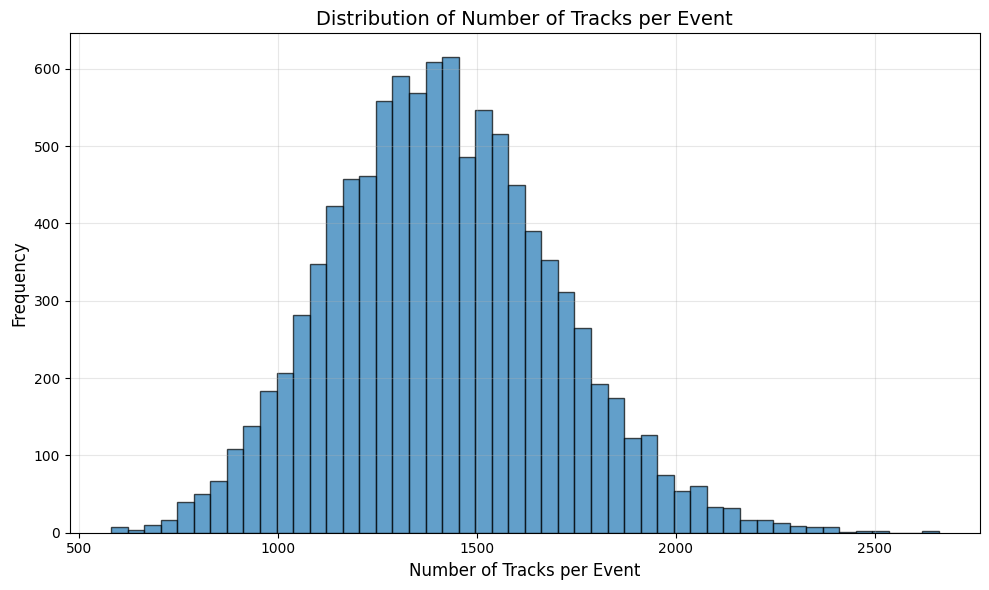


绘图完成！


In [2]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob

# 获取所有ROOT文件
root_files = sorted(glob.glob("/data/bfys/shenzh/4Dtracking/hepattn/data/lhcb/version3/*.root"))

# 用于统计每个event的track数量
event_track_counts = []

# 遍历所有文件
for file_path in root_files:
    print(f"处理文件: {file_path.split('/')[-1]}")

    # 打开ROOT文件
    root_file = uproot.open(file_path)

    # 读取树
    tree = root_file["velo_kalman_filter/monitor_tree"]

    # 读取event_number
    event_numbers = tree["event_number"].array(library="np")

    # 统计每个event_number的出现次数（即track数量）
    unique_events, counts = np.unique(event_numbers, return_counts=True)

    # 添加到总的统计中
    event_track_counts.extend(counts)

    root_file.close()

# 转换为numpy数组
event_track_counts = np.array(event_track_counts)

print(f"\n总共有 {len(event_track_counts)} 个events")
print(f"每个event的track数量统计:")
print(f"  最小值: {event_track_counts.min()}")
print(f"  最大值: {event_track_counts.max()}")
print(f"  平均值: {event_track_counts.mean():.2f}")
print(f"  中位数: {np.median(event_track_counts):.2f}")

# 绘制分布图
plt.figure(figsize=(10, 6))
plt.hist(event_track_counts, bins=50, edgecolor="black", alpha=0.7)
plt.xlabel("Number of Tracks per Event", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Number of Tracks per Event", fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n绘图完成！")

In [3]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob

# 获取所有ROOT文件
root_files = sorted(glob.glob("/data/bfys/shenzh/4Dtracking/hepattn/data/lhcb/version3/*.root"))

# 先看一个文件的数据，了解浮点数精度
test_file = uproot.open(root_files[0])
tree = test_file["velo_kalman_filter/monitor_tree"]

# 读取所有需要的分支
ovtx_x = tree["ovtx_x"].array(library="np")
ovtx_y = tree["ovtx_y"].array(library="np")
ovtx_z = tree["ovtx_z"].array(library="np")
ovtx_t = tree["ovtx_t"].array(library="np")
fromPV = tree["fromPV"].array(library="np")
event_number = tree["event_number"].array(library="np")

# 只看fromPV==1的数据
pv_mask = fromPV == 1
print(f"总entries: {len(fromPV)}")
print(f"fromPV==1的entries: {np.sum(pv_mask)}")

# 看看前几个顶点坐标的精度
print(f"\n前10个fromPV==1的顶点坐标:")
for i in range(min(10, np.sum(pv_mask))):
    idx = np.where(pv_mask)[0][i]
    print(f"  x={ovtx_x[idx]:.10f}, y={ovtx_y[idx]:.10f}, z={ovtx_z[idx]:.10f}, t={ovtx_t[idx]:.10f}, event={event_number[idx]}")

test_file.close()

总entries: 139270
fromPV==1的entries: 116313

前10个fromPV==1的顶点坐标:
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0


In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob

# 获取所有ROOT文件
root_files = sorted(glob.glob("/data/bfys/shenzh/4Dtracking/hepattn/data/lhcb/version3/*.root"))

# 先看一个文件的数据，了解浮点数精度
test_file = uproot.open(root_files[0])
tree = test_file["velo_kalman_filter/monitor_tree"]

# 读取所有需要的分支
ovtx_x = tree["ovtx_x"].array(library="np")
ovtx_y = tree["ovtx_y"].array(library="np")
ovtx_z = tree["ovtx_z"].array(library="np")
ovtx_t = tree["ovtx_t"].array(library="np")
fromPV = tree["fromPV"].array(library="np")
event_number = tree["event_number"].array(library="np")

# 只看fromPV==1的数据
pv_mask = fromPV == 1
print(f"总entries: {len(fromPV)}")
print(f"fromPV==1的entries: {np.sum(pv_mask)}")

# 看看前几个顶点坐标的精度
print(f"\n前10个fromPV==1的顶点坐标:")
for i in range(min(10, np.sum(pv_mask))):
    idx = np.where(pv_mask)[0][i]
    print(f"  x={ovtx_x[idx]:.10f}, y={ovtx_y[idx]:.10f}, z={ovtx_z[idx]:.10f}, t={ovtx_t[idx]:.10f}, event={event_number[idx]}")

test_file.close()

总entries: 139270
fromPV==1的entries: 116313

前10个fromPV==1的顶点坐标:
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0
  x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895, event=0


In [5]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob
import pandas as pd

# 获取所有ROOT文件
root_files = sorted(glob.glob("/data/bfys/shenzh/4Dtracking/hepattn/data/lhcb/version3/*.root"))

# 存储所有event的主顶点信息
all_primary_vertices = []

# 遍历所有文件
for file_idx, file_path in enumerate(root_files):
    if file_idx % 10 == 0:
        print(f"处理第 {file_idx + 1}/{len(root_files)} 个文件...")

    # 打开ROOT文件
    root_file = uproot.open(file_path)
    tree = root_file["velo_kalman_filter/monitor_tree"]

    # 读取所有需要的分支
    ovtx_x = tree["ovtx_x"].array(library="np")
    ovtx_y = tree["ovtx_y"].array(library="np")
    ovtx_z = tree["ovtx_z"].array(library="np")
    ovtx_t = tree["ovtx_t"].array(library="np")
    fromPV = tree["fromPV"].array(library="np")
    event_number = tree["event_number"].array(library="np")

    # 只选择fromPV==1的track
    pv_mask = fromPV == 1

    # 提取fromPV==1的数据
    pv_x = ovtx_x[pv_mask]
    pv_y = ovtx_y[pv_mask]
    pv_z = ovtx_z[pv_mask]
    pv_t = ovtx_t[pv_mask]
    pv_events = event_number[pv_mask]

    # 对每个event，找到唯一的主顶点
    unique_events = np.unique(pv_events)

    for event in unique_events:
        event_mask = pv_events == event
        # 由于同一个event的所有fromPV==1的track都有相同的ovtx，取第一个即可
        idx = np.where(event_mask)[0][0]

        all_primary_vertices.append({
            "file_idx": file_idx,
            "event_number": event,
            "ovtx_x": pv_x[idx],
            "ovtx_y": pv_y[idx],
            "ovtx_z": pv_z[idx],
            "ovtx_t": pv_t[idx],
            "n_tracks_from_pv": np.sum(event_mask),  # 这个event有多少个来自PV的track
        })

    root_file.close()

# 转换为DataFrame
df_pv = pd.DataFrame(all_primary_vertices)

print(f"\n总共提取了 {len(df_pv)} 个events的主顶点信息")
print(f"\n主顶点DataFrame的前几行:")
print(df_pv.head(10))
print(f"\n统计信息:")
print(df_pv.describe())

处理第 1/100 个文件...
处理第 11/100 个文件...
处理第 21/100 个文件...
处理第 31/100 个文件...
处理第 41/100 个文件...
处理第 51/100 个文件...
处理第 61/100 个文件...
处理第 71/100 个文件...
处理第 81/100 个文件...
处理第 91/100 个文件...

总共提取了 10000 个events的主顶点信息

主顶点DataFrame的前几行:
   file_idx  event_number  ovtx_x  ovtx_y      ovtx_z    ovtx_t  \
0         0             0 -0.0124  0.0277   32.537701  0.085373   
1         0             1 -0.0221  0.0366  -50.486301  0.024971   
2         0             2  0.0254  0.0192   83.318398 -0.269976   
3         0             3  0.0493  0.0139   -2.202000 -0.065081   
4         0             4 -0.0124 -0.0092   27.892700 -0.123362   
5         0             5 -0.0013  0.0246  -21.751801  0.207396   
6         0             6  0.0014  0.0085    1.727100  0.074312   
7         0             7  0.0024 -0.0164   28.759501  0.189353   
8         0             8  0.0038  0.0215  -10.947600  0.108659   
9         0             9  0.0280 -0.0162  120.861000  0.212764   

   n_tracks_from_pv  
0              

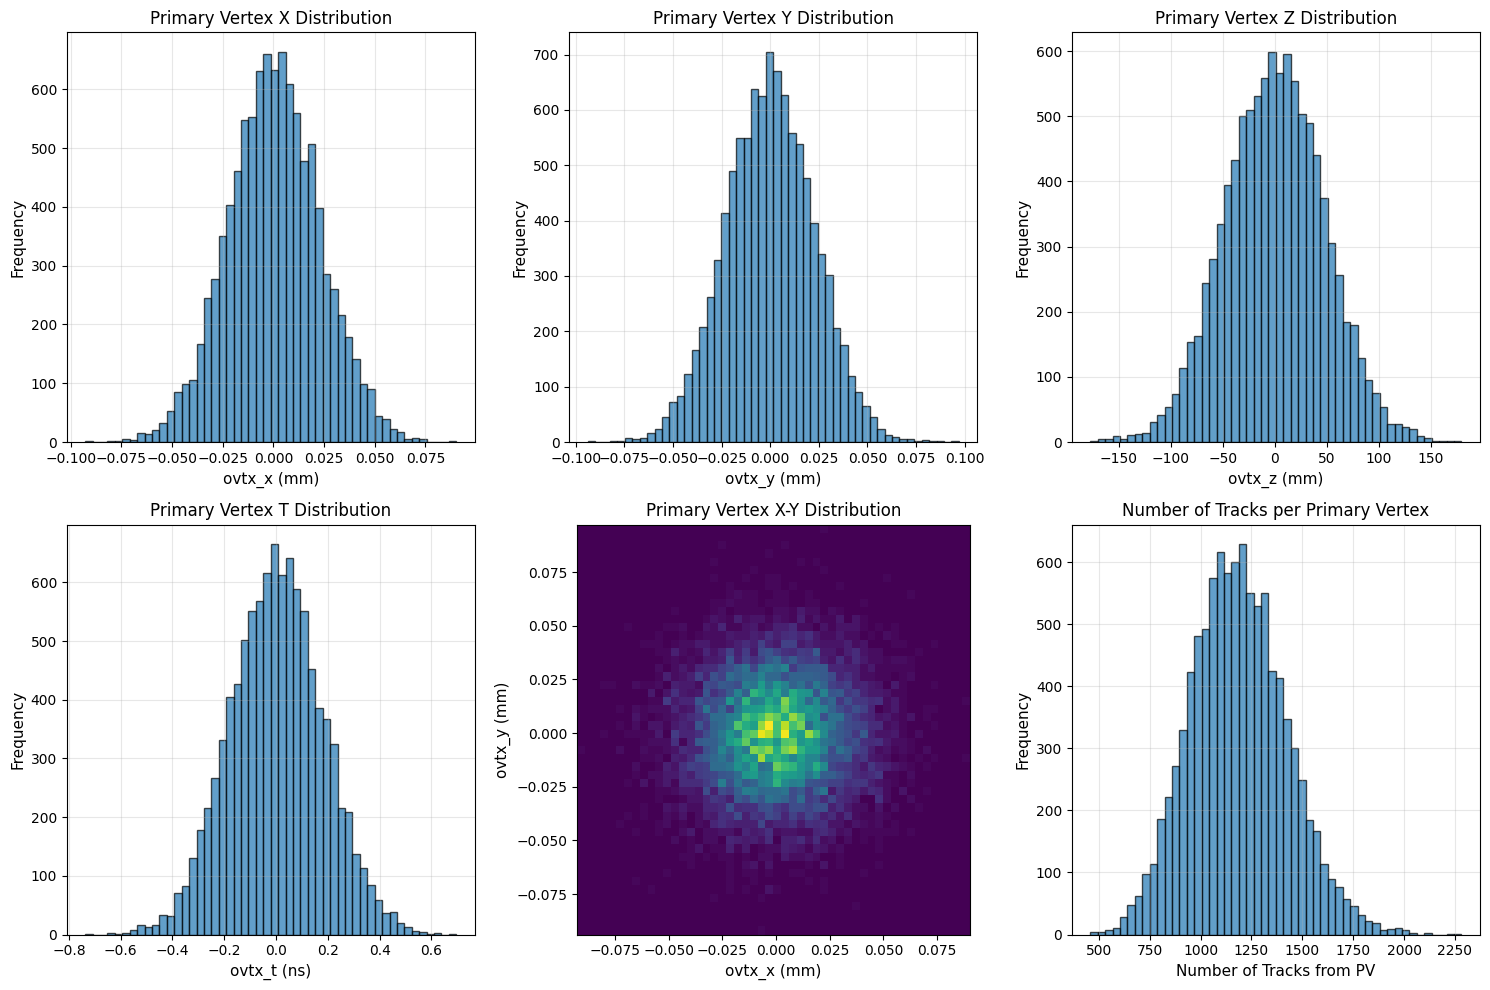

所有主顶点的分布图绘制完成！


In [6]:
# 绘制主顶点的位置分布
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# x坐标分布
axes[0, 0].hist(df_pv["ovtx_x"], bins=50, edgecolor="black", alpha=0.7)
axes[0, 0].set_xlabel("ovtx_x (mm)", fontsize=11)
axes[0, 0].set_ylabel("Frequency", fontsize=11)
axes[0, 0].set_title("Primary Vertex X Distribution", fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# y坐标分布
axes[0, 1].hist(df_pv["ovtx_y"], bins=50, edgecolor="black", alpha=0.7)
axes[0, 1].set_xlabel("ovtx_y (mm)", fontsize=11)
axes[0, 1].set_ylabel("Frequency", fontsize=11)
axes[0, 1].set_title("Primary Vertex Y Distribution", fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# z坐标分布
axes[0, 2].hist(df_pv["ovtx_z"], bins=50, edgecolor="black", alpha=0.7)
axes[0, 2].set_xlabel("ovtx_z (mm)", fontsize=11)
axes[0, 2].set_ylabel("Frequency", fontsize=11)
axes[0, 2].set_title("Primary Vertex Z Distribution", fontsize=12)
axes[0, 2].grid(True, alpha=0.3)

# t坐标分布
axes[1, 0].hist(df_pv["ovtx_t"], bins=50, edgecolor="black", alpha=0.7)
axes[1, 0].set_xlabel("ovtx_t (ns)", fontsize=11)
axes[1, 0].set_ylabel("Frequency", fontsize=11)
axes[1, 0].set_title("Primary Vertex T Distribution", fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# x-y 2D分布
axes[1, 1].hist2d(df_pv["ovtx_x"], df_pv["ovtx_y"], bins=50, cmap="viridis")
axes[1, 1].set_xlabel("ovtx_x (mm)", fontsize=11)
axes[1, 1].set_ylabel("ovtx_y (mm)", fontsize=11)
axes[1, 1].set_title("Primary Vertex X-Y Distribution", fontsize=12)
axes[1, 1].set_aspect("equal")

# 每个主顶点的track数量分布
axes[1, 2].hist(df_pv["n_tracks_from_pv"], bins=50, edgecolor="black", alpha=0.7)
axes[1, 2].set_xlabel("Number of Tracks from PV", fontsize=11)
axes[1, 2].set_ylabel("Frequency", fontsize=11)
axes[1, 2].set_title("Number of Tracks per Primary Vertex", fontsize=12)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"所有主顶点的分布图绘制完成！")

In [7]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import glob
import pandas as pd

# 获取所有ROOT文件
root_files = sorted(glob.glob("/data/bfys/shenzh/4Dtracking/hepattn/data/lhcb/version3/*.root"))

# 存储所有主顶点信息
all_primary_vertices = []

# 遍历所有文件
for file_idx, file_path in enumerate(root_files):
    if file_idx % 10 == 0:
        print(f"处理第 {file_idx + 1}/{len(root_files)} 个文件...")

    # 打开ROOT文件
    root_file = uproot.open(file_path)
    tree = root_file["velo_kalman_filter/monitor_tree"]

    # 读取所有需要的分支
    ovtx_x = tree["ovtx_x"].array(library="np")
    ovtx_y = tree["ovtx_y"].array(library="np")
    ovtx_z = tree["ovtx_z"].array(library="np")
    ovtx_t = tree["ovtx_t"].array(library="np")
    fromPV = tree["fromPV"].array(library="np")
    event_number = tree["event_number"].array(library="np")

    # 只选择fromPV==1的track
    pv_mask = fromPV == 1

    # 提取fromPV==1的数据
    pv_x = ovtx_x[pv_mask]
    pv_y = ovtx_y[pv_mask]
    pv_z = ovtx_z[pv_mask]
    pv_t = ovtx_t[pv_mask]
    pv_events = event_number[pv_mask]

    # 对每个event，找到唯一的主顶点（基于x,y,z,t坐标）
    unique_events = np.unique(pv_events)

    for event in unique_events:
        event_mask = pv_events == event
        event_indices = np.where(event_mask)[0]

        # 提取这个event的所有顶点坐标
        event_x = pv_x[event_indices]
        event_y = pv_y[event_indices]
        event_z = pv_z[event_indices]
        event_t = pv_t[event_indices]

        # 找到唯一的顶点（基于x,y,z,t的组合）
        # 将4D坐标组合成一个数组
        vertex_coords = np.column_stack([event_x, event_y, event_z, event_t])

        # 使用numpy的unique函数找到唯一的顶点
        unique_vertices, vertex_indices, vertex_counts = np.unique(vertex_coords, axis=0, return_index=True, return_counts=True)

        # 对每个唯一的顶点，记录其信息
        for vtx_idx, (vtx_coord, n_tracks) in enumerate(zip(unique_vertices, vertex_counts)):
            all_primary_vertices.append({
                "file_idx": file_idx,
                "event_number": event,
                "ovtx_x": vtx_coord[0],
                "ovtx_y": vtx_coord[1],
                "ovtx_z": vtx_coord[2],
                "ovtx_t": vtx_coord[3],
                "n_tracks_from_pv": n_tracks,  # 这个顶点有多少个track
            })

    root_file.close()

# 转换为DataFrame
df_pv = pd.DataFrame(all_primary_vertices)

print(f"\n总共提取了 {len(df_pv)} 个主顶点")
print(f"来自 {len(np.unique(df_pv[['file_idx', 'event_number']].values, axis=0))} 个events")
print(f"\n主顶点DataFrame的前几行:")
print(df_pv.head(20))
print(f"\n统计信息:")
print(df_pv.describe())

# 统计每个event有多少个主顶点
event_pv_counts = df_pv.groupby(["file_idx", "event_number"]).size()
print(f"\n每个event的主顶点数量统计:")
print(f"  最小值: {event_pv_counts.min()}")
print(f"  最大值: {event_pv_counts.max()}")
print(f"  平均值: {event_pv_counts.mean():.2f}")
print(f"  中位数: {event_pv_counts.median():.2f}")

处理第 1/100 个文件...
处理第 11/100 个文件...
处理第 21/100 个文件...
处理第 31/100 个文件...
处理第 41/100 个文件...
处理第 51/100 个文件...
处理第 61/100 个文件...
处理第 71/100 个文件...
处理第 81/100 个文件...
处理第 91/100 个文件...

总共提取了 397399 个主顶点
来自 10000 个events

主顶点DataFrame的前几行:
    file_idx  event_number  ovtx_x  ovtx_y     ovtx_z    ovtx_t  \
0          0             0 -0.0479  0.0171 -48.341202 -0.012892   
1          0             0 -0.0372  0.0396   7.616800 -0.234542   
2          0             0 -0.0278  0.0017  65.435997 -0.108682   
3          0             0 -0.0268  0.0135 -16.097601  0.163609   
4          0             0 -0.0230 -0.0302  69.699997  0.032409   
5          0             0 -0.0229  0.0055 -38.491402  0.341535   
6          0             0 -0.0152 -0.0107 -33.943802  0.101536   
7          0             0 -0.0141  0.0241  -6.460100  0.237469   
8          0             0 -0.0124  0.0277  32.537701  0.085373   
9          0             0 -0.0083  0.0310  52.152802  0.500012   
10         0             0 -0

In [8]:
unique_vertices

array([[-5.7500001e-02,  9.9999997e-05,  4.0061199e+01, -1.7681929e-01],
       [-4.8599999e-02, -8.9999998e-04, -5.1611698e+01,  5.8248617e-02],
       [-3.3399999e-02,  1.5100000e-02, -4.8387501e+01, -2.6156759e-01],
       [-3.1099999e-02,  2.7799999e-02,  6.2038999e+00,  1.0185785e-01],
       [-2.9300001e-02, -5.7999999e-03,  1.9460300e+01, -1.7004387e-01],
       [-2.6900001e-02, -1.6799999e-02,  4.2600601e+01,  1.2700941e-01],
       [-2.4800001e-02, -5.1000002e-03, -1.5505900e+01, -3.5629120e-01],
       [-2.4499999e-02,  6.0899999e-02, -2.6420300e+01, -5.7640366e-02],
       [-1.3300000e-02, -2.4200000e-02,  5.4877102e+01,  1.7364396e-01],
       [-1.3000000e-02, -7.6000001e-03, -2.0676201e+01, -1.5556068e-02],
       [-1.0800000e-02, -3.0000000e-03,  5.3492001e+01,  1.0728801e-01],
       [-7.7999998e-03,  8.7000001e-03, -3.6111500e+01,  2.3727122e-01],
       [-6.8000001e-03,  2.8999999e-02,  1.9282600e+01,  1.1369116e-01],
       [-6.0000001e-03,  2.3600001e-02, -6.6352898e

In [9]:
# 先检查一下同一个event中，相似顶点之间的最小距离
test_file = uproot.open(root_files[0])
tree = test_file["velo_kalman_filter/monitor_tree"]

ovtx_x = tree["ovtx_x"].array(library="np")
ovtx_y = tree["ovtx_y"].array(library="np")
ovtx_z = tree["ovtx_z"].array(library="np")
ovtx_t = tree["ovtx_t"].array(library="np")
fromPV = tree["fromPV"].array(library="np")
event_number = tree["event_number"].array(library="np")

# 只看fromPV==1的第一个event
pv_mask = fromPV == 1
event_0_mask = (event_number == 0) & pv_mask

e0_x = ovtx_x[event_0_mask]
e0_y = ovtx_y[event_0_mask]
e0_z = ovtx_z[event_0_mask]
e0_t = ovtx_t[event_0_mask]

# 看看这些坐标
print(f"Event 0中fromPV==1的track数: {len(e0_x)}")
print(f"\n前20个顶点坐标:")
for i in range(min(20, len(e0_x))):
    print(f"  {i}: x={e0_x[i]:.10f}, y={e0_y[i]:.10f}, z={e0_z[i]:.10f}, t={e0_t[i]:.10f}")

# 找到唯一的顶点（精确匹配）
vertex_coords = np.column_stack([e0_x, e0_y, e0_z, e0_t])
unique_vertices_exact = np.unique(vertex_coords, axis=0)
print(f"\n精确匹配的唯一顶点数: {len(unique_vertices_exact)}")

# 计算任意两个不同顶点之间的最小距离
if len(unique_vertices_exact) > 1:
    from scipy.spatial.distance import pdist

    distances = pdist(unique_vertices_exact)
    print(f"\n不同顶点之间的最小距离: {np.min(distances):.10f}")
    print(f"不同顶点之间的距离中位数: {np.median(distances):.10f}")

test_file.close()

Event 0中fromPV==1的track数: 806

前20个顶点坐标:
  0: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  1: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  2: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  3: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  4: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  5: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  6: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  7: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  8: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  9: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  10: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  11: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  12: x=-0.0124000004, y=0.0276999995, z=32.5377006531, t=0.0853725895
  13: x=-0.0124000004, y=0.0276999995, z=32.53

In [10]:
# 使用容差的版本（更稳健）
# 定义容差：空间坐标0.001mm，时间0.001ns
tolerance_xyz = 0.0001  # mm
tolerance_t = 0.0001  # ns


def find_unique_vertices_with_tolerance(x, y, z, t, tol_xyz=0.001, tol_t=0.001):
    """
    使用容差找到唯一的顶点
    """
    if len(x) == 0:
        return np.array([]), np.array([])

    # 四舍五入到合理的精度
    # 根据容差确定小数位数
    decimals_xyz = int(-np.log10(tol_xyz))
    decimals_t = int(-np.log10(tol_t))

    x_rounded = np.round(x, decimals_xyz)
    y_rounded = np.round(y, decimals_xyz)
    z_rounded = np.round(z, decimals_xyz)
    t_rounded = np.round(t, decimals_t)

    # 组合坐标
    vertex_coords = np.column_stack([x_rounded, y_rounded, z_rounded, t_rounded])

    # 找到唯一的顶点
    unique_vertices, vertex_indices, vertex_counts = np.unique(vertex_coords, axis=0, return_index=True, return_counts=True)

    return unique_vertices, vertex_counts


# 测试一下这个函数
test_unique, test_counts = find_unique_vertices_with_tolerance(e0_x, e0_y, e0_z, e0_t)
print(f"使用容差方法找到的唯一顶点数: {len(test_unique)}")
print(f"前10个顶点及其track数:")
for i in range(min(10, len(test_unique))):
    print(
        f"  顶点{i}: x={test_unique[i, 0]:.4f}, y={test_unique[i, 1]:.4f}, z={test_unique[i, 2]:.4f}, t={test_unique[i, 3]:.4f}, n_tracks={test_counts[i]}"
    )

使用容差方法找到的唯一顶点数: 29
前10个顶点及其track数:
  顶点0: x=-0.0480, y=0.0170, z=-48.3410, t=-0.0130, n_tracks=56
  顶点1: x=-0.0370, y=0.0400, z=7.6170, t=-0.2350, n_tracks=112
  顶点2: x=-0.0280, y=0.0020, z=65.4360, t=-0.1090, n_tracks=25
  顶点3: x=-0.0270, y=0.0140, z=-16.0980, t=0.1640, n_tracks=36
  顶点4: x=-0.0230, y=-0.0300, z=69.7000, t=0.0320, n_tracks=13
  顶点5: x=-0.0230, y=0.0060, z=-38.4910, t=0.3420, n_tracks=14
  顶点6: x=-0.0150, y=-0.0110, z=-33.9440, t=0.1020, n_tracks=62
  顶点7: x=-0.0140, y=0.0240, z=-6.4600, t=0.2370, n_tracks=8
  顶点8: x=-0.0120, y=0.0280, z=32.5380, t=0.0850, n_tracks=14
  顶点9: x=-0.0080, y=0.0310, z=52.1530, t=0.5000, n_tracks=20


In [11]:
# 使用容差方法重新处理所有数据
all_primary_vertices_v2 = []

# 遍历所有文件
for file_idx, file_path in enumerate(root_files):
    if file_idx % 10 == 0:
        print(f"处理第 {file_idx + 1}/{len(root_files)} 个文件...")

    # 打开ROOT文件
    root_file = uproot.open(file_path)
    tree = root_file["velo_kalman_filter/monitor_tree"]

    # 读取所有需要的分支
    ovtx_x = tree["ovtx_x"].array(library="np")
    ovtx_y = tree["ovtx_y"].array(library="np")
    ovtx_z = tree["ovtx_z"].array(library="np")
    ovtx_t = tree["ovtx_t"].array(library="np")
    fromPV = tree["fromPV"].array(library="np")
    event_number = tree["event_number"].array(library="np")

    # 只选择fromPV==1的track
    pv_mask = fromPV == 1

    # 提取fromPV==1的数据
    pv_x = ovtx_x[pv_mask]
    pv_y = ovtx_y[pv_mask]
    pv_z = ovtx_z[pv_mask]
    pv_t = ovtx_t[pv_mask]
    pv_events = event_number[pv_mask]

    # 对每个event，找到唯一的主顶点
    unique_events = np.unique(pv_events)

    for event in unique_events:
        event_mask = pv_events == event
        event_indices = np.where(event_mask)[0]

        # 提取这个event的所有顶点坐标
        event_x = pv_x[event_indices]
        event_y = pv_y[event_indices]
        event_z = pv_z[event_indices]
        event_t = pv_t[event_indices]

        # 使用容差方法找到唯一的顶点
        unique_vertices, vertex_counts = find_unique_vertices_with_tolerance(event_x, event_y, event_z, event_t, tol_xyz=0.001, tol_t=0.001)

        # 对每个唯一的顶点，记录其信息
        for vtx_coord, n_tracks in zip(unique_vertices, vertex_counts):
            all_primary_vertices_v2.append({
                "file_idx": file_idx,
                "event_number": event,
                "ovtx_x": vtx_coord[0],
                "ovtx_y": vtx_coord[1],
                "ovtx_z": vtx_coord[2],
                "ovtx_t": vtx_coord[3],
                "n_tracks_from_pv": n_tracks,
            })

    root_file.close()

# 转换为DataFrame
df_pv_v2 = pd.DataFrame(all_primary_vertices_v2)

print(f"\n使用容差方法:")
print(f"总共提取了 {len(df_pv_v2)} 个主顶点")
print(f"来自 {len(np.unique(df_pv_v2[['file_idx', 'event_number']].values, axis=0))} 个events")

# 统计每个event有多少个主顶点
event_pv_counts_v2 = df_pv_v2.groupby(["file_idx", "event_number"]).size()
print(f"\n每个event的主顶点数量统计:")
print(f"  最小值: {event_pv_counts_v2.min()}")
print(f"  最大值: {event_pv_counts_v2.max()}")
print(f"  平均值: {event_pv_counts_v2.mean():.2f}")
print(f"  中位数: {event_pv_counts_v2.median():.2f}")

print(f"\n与之前精确匹配方法的比较:")
print(f"  精确匹配: {len(df_pv)} 个主顶点")
print(f"  容差方法: {len(df_pv_v2)} 个主顶点")
print(f"  差异: {len(df_pv) - len(df_pv_v2)} 个 ({100 * (len(df_pv) - len(df_pv_v2)) / len(df_pv):.2f}%)")

处理第 1/100 个文件...


处理第 11/100 个文件...
处理第 21/100 个文件...
处理第 31/100 个文件...
处理第 41/100 个文件...
处理第 51/100 个文件...
处理第 61/100 个文件...
处理第 71/100 个文件...
处理第 81/100 个文件...
处理第 91/100 个文件...

使用容差方法:
总共提取了 397359 个主顶点
来自 10000 个events

每个event的主顶点数量统计:
  最小值: 19
  最大值: 65
  平均值: 39.74
  中位数: 40.00

与之前精确匹配方法的比较:
  精确匹配: 397399 个主顶点
  容差方法: 397359 个主顶点
  差异: 40 个 (0.01%)


In [17]:
vertex_counts

array([38,  8, 67, 13, 50, 21, 45, 25,  1, 88, 22,  7, 23, 19, 63, 13, 12,
       14, 57, 72, 21, 55, 14, 14,  1, 16, 25])

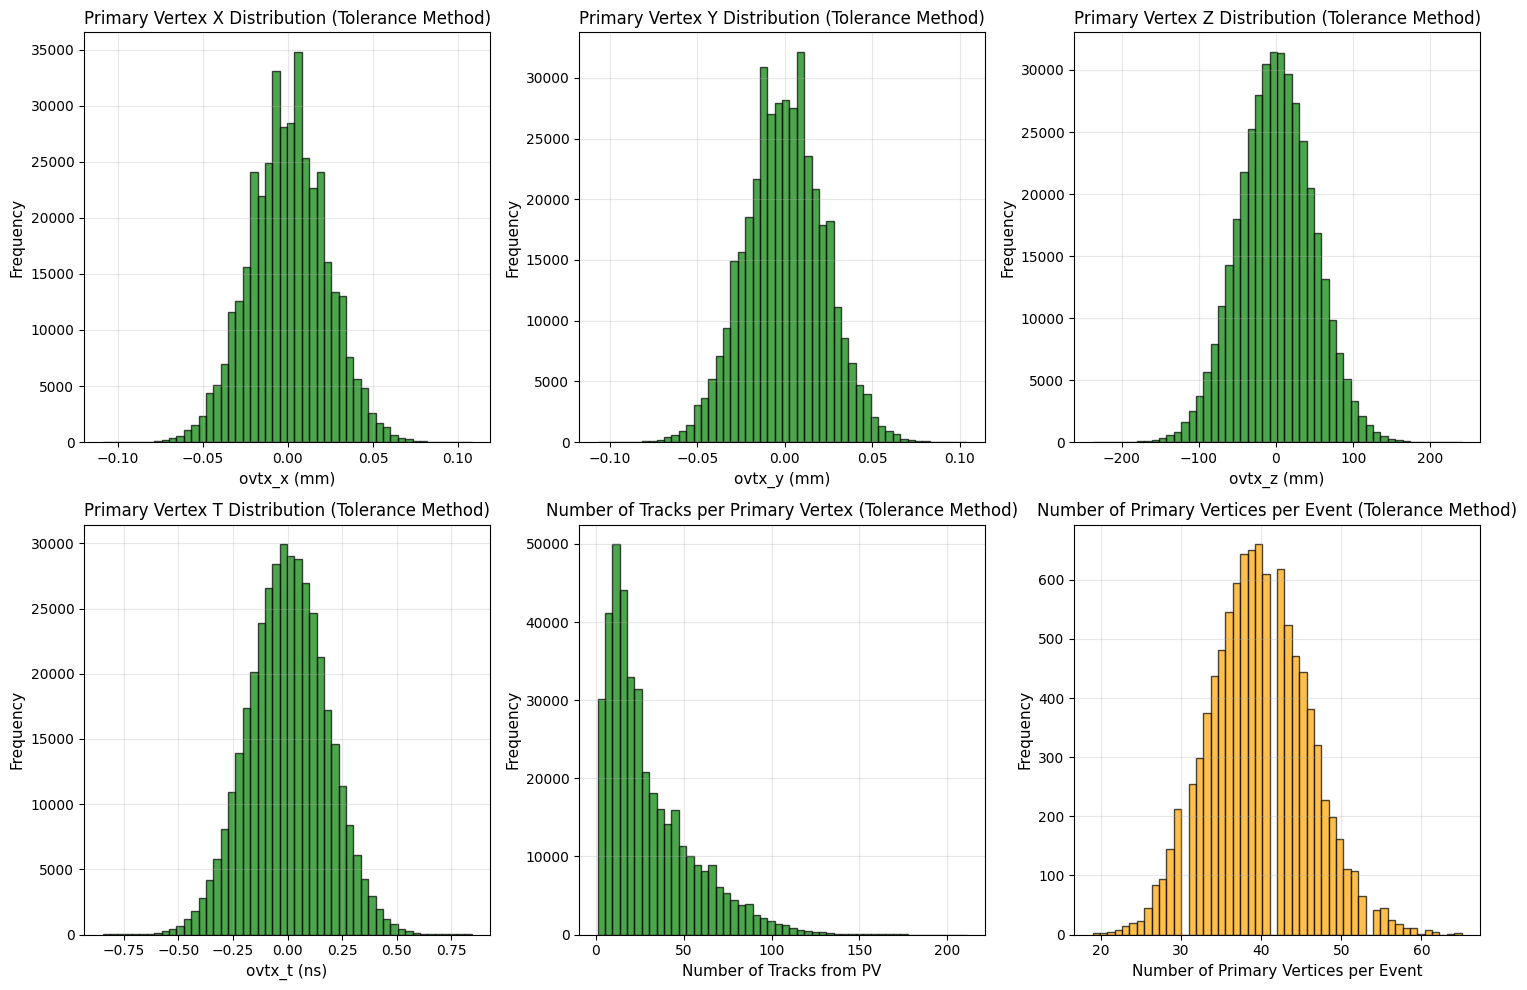

容差方法的主顶点分布图绘制完成！

统计信息:
总主顶点数: 397359
每个event的主顶点数 - 最小值: 19, 最大值: 65, 平均值: 39.74


In [12]:
# 绘制容差方法的主顶点分布
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# x坐标分布
axes[0, 0].hist(df_pv_v2["ovtx_x"], bins=50, edgecolor="black", alpha=0.7, color="green")
axes[0, 0].set_xlabel("ovtx_x (mm)", fontsize=11)
axes[0, 0].set_ylabel("Frequency", fontsize=11)
axes[0, 0].set_title("Primary Vertex X Distribution (Tolerance Method)", fontsize=12)
axes[0, 0].grid(True, alpha=0.3)

# y坐标分布
axes[0, 1].hist(df_pv_v2["ovtx_y"], bins=50, edgecolor="black", alpha=0.7, color="green")
axes[0, 1].set_xlabel("ovtx_y (mm)", fontsize=11)
axes[0, 1].set_ylabel("Frequency", fontsize=11)
axes[0, 1].set_title("Primary Vertex Y Distribution (Tolerance Method)", fontsize=12)
axes[0, 1].grid(True, alpha=0.3)

# z坐标分布
axes[0, 2].hist(df_pv_v2["ovtx_z"], bins=50, edgecolor="black", alpha=0.7, color="green")
axes[0, 2].set_xlabel("ovtx_z (mm)", fontsize=11)
axes[0, 2].set_ylabel("Frequency", fontsize=11)
axes[0, 2].set_title("Primary Vertex Z Distribution (Tolerance Method)", fontsize=12)
axes[0, 2].grid(True, alpha=0.3)

# t坐标分布
axes[1, 0].hist(df_pv_v2["ovtx_t"], bins=50, edgecolor="black", alpha=0.7, color="green")
axes[1, 0].set_xlabel("ovtx_t (ns)", fontsize=11)
axes[1, 0].set_ylabel("Frequency", fontsize=11)
axes[1, 0].set_title("Primary Vertex T Distribution (Tolerance Method)", fontsize=12)
axes[1, 0].grid(True, alpha=0.3)

# 每个主顶点的track数量分布
axes[1, 1].hist(df_pv_v2["n_tracks_from_pv"], bins=50, edgecolor="black", alpha=0.7, color="green")
axes[1, 1].set_xlabel("Number of Tracks from PV", fontsize=11)
axes[1, 1].set_ylabel("Frequency", fontsize=11)
axes[1, 1].set_title("Number of Tracks per Primary Vertex (Tolerance Method)", fontsize=12)
axes[1, 1].grid(True, alpha=0.3)

# 每个event的主顶点数量分布
event_pv_counts_v2 = df_pv_v2.groupby(["file_idx", "event_number"]).size()
axes[1, 2].hist(event_pv_counts_v2, bins=50, edgecolor="black", alpha=0.7, color="orange")
axes[1, 2].set_xlabel("Number of Primary Vertices per Event", fontsize=11)
axes[1, 2].set_ylabel("Frequency", fontsize=11)
axes[1, 2].set_title("Number of Primary Vertices per Event (Tolerance Method)", fontsize=12)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"容差方法的主顶点分布图绘制完成！")
print(f"\n统计信息:")
print(f"总主顶点数: {len(df_pv_v2)}")
print(f"每个event的主顶点数 - 最小值: {event_pv_counts_v2.min()}, 最大值: {event_pv_counts_v2.max()}, 平均值: {event_pv_counts_v2.mean():.2f}")

In [13]:
import h5py

f = h5py.File("/data/bfys/shenzh/4Dtracking/hepattn/data/lhcb/version3_hdf5/val.h5", "r")
print(list(f.keys()))
print(f.attrs.keys())
print(f.attrs["branch_names"], f.attrs["dataset_type"], f.attrs["num_events"], f.attrs["num_tracks"])

['event_info', 'tracks', 'vertices']
<KeysViewHDF5 ['branch_names', 'dataset_type', 'num_events', 'num_tracks', 'num_vertices']>
['beamPOCA_tx' 'beamPOCA_ty' 'beamPOCA_x' 'beamPOCA_y' 'beamPOCA_z'
 'beamPOCA_t' 'backward' 'true_eta' 'ovtx_x' 'ovtx_y' 'ovtx_z' 'ovtx_t'
 'tx_true' 'ty_true' 'c00' 'c11' 'c33' 'c55' 'c31' 'fromPV' 'chi2'
 'event_number'] validation 2000 2825778


In [14]:
g = f["event_info"]

In [15]:
print(list(g.keys()))


['event_indices', 'event_numbers']


In [16]:
g["event_start_indices"]

KeyError: "Unable to synchronously open object (object 'event_start_indices' doesn't exist)"

In [ ]:
g["event_start_indices"][:9000]

array([      0,    1658,    2843, ..., 2823380, 2824844, 2825778],
      shape=(2001,))

In [ ]:
g2 = f["tracks"]

In [ ]:
g2.keys()

<KeysViewHDF5 ['backward', 'beamPOCA_t', 'beamPOCA_tx', 'beamPOCA_ty', 'beamPOCA_x', 'beamPOCA_y', 'beamPOCA_z', 'c00', 'c11', 'c20', 'c22', 'c31', 'c33', 'c55', 'chi2', 'event_number', 'fromPV', 'ovtx_t', 'ovtx_x', 'ovtx_y', 'ovtx_z', 'p', 'pt', 'true_eta', 'tx_true', 'ty_true']>

In [ ]:
g2["backward"]

<HDF5 dataset "backward": shape (2825778,), type "|b1">

In [ ]:
g["event_start_indices"][:]

array([      0,    1658,    2843, ..., 2823380, 2824844, 2825778],
      shape=(2001,))

In [ ]:
g2["event_number"][1657]

np.uint32(0)

In [ ]:
f.attrs.keys()

<KeysViewHDF5 ['branch_names', 'dataset_type', 'num_events', 'num_tracks']>

In [ ]:
f.attrs["branch_names"], f.attrs["dataset_type"], f.attrs["num_events"], f.attrs["num_tracks"]

(array(['beamPOCA_tx', 'beamPOCA_ty', 'beamPOCA_x', 'beamPOCA_y',
        'beamPOCA_z', 'beamPOCA_t', 'backward', 'true_eta', 'ovtx_x',
        'ovtx_y', 'ovtx_z', 'ovtx_t', 'p', 'pt', 'tx_true', 'ty_true',
        'c00', 'c11', 'c22', 'c33', 'c55', 'c20', 'c31', 'fromPV', 'chi2',
        'event_number'], dtype=object),
 'validation',
 np.int64(2000),
 np.int64(2825778))